## Optimization: Gradient Descent
In this notebook, we will solve a simple linear regression problem by gradient descent. We will see the effect of the learning rate on the trajectory in parameter space. We will show how Stochastic Gradient Descent (SGD) differs from the standard version, and the effect of "shuffling" your data during SGD.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.linear_model import LinearRegression

In [8]:
# generate synthetic data using np
np.random.seed(1234)

observations = 100

x1 = np.random.uniform(0, 10, observations)
x2 = np.random.uniform(0, 10, observations)
constant = np.ones(observations)
epsilon = np.random.normal(0, .5, observations)

bias = 1.5
theta_1 = 2
theta_2 = 5

y = bias * constant + theta_1 * x1 + theta_2 * x2
x_matrix = np.array([constant, x1, x2]).T

Solve the problem two ways: 
1. By using the scikit-learn LinearRegression model
2. Using matrix algebra directly via the formula $\theta = (X^T X)^{-1}X^Ty$

In [9]:
lr = LinearRegression(fit_intercept=False)
lr.fit(x_matrix, y)

lr.coef_

array([1.5, 2. , 5. ])

In [10]:
# using the formula
theta = np.linalg.inv(np.dot(x_matrix.T, x_matrix)).dot(x_matrix.T).dot(y)
theta

array([1.5, 2. , 5. ])

## Solving by Gradient Descent


For most numerical problems, we don't / can't know the underlying analytical solution. This is because we only arrive at analytical solutions by solving the equations mathematically, with pen and paper. That is more often than not just impossible. Fortunately, we have a way of converging to an approximate solution, by using **Gradient Descent**.


We will explore this very useful method because Neural Networks, along with many other complicated algorithms, are trained using Gradient Descent.  Seeing how gradient descent works on a simple example will build intuition and help us understand some of the nuances around setting the learning rate and other parameters.  We will also explore Stochastic Gradient Descent and compare its behavior to the standard approach.

## Exercise

The next several cells have code to perform (full-batch) gradient descent.  We have omitted some parameters for you to fill in.

1. Pick a learning rate, and a number of iterations, run the code, and then plot the trajectory of your gradient descent.
1. Find examples where the learning rate is too high, too low, and "just right".
1. Look at plots of loss function under these conditions.

In [11]:
def gradient_descent(learning_rate, num_iter, theta_initial):

    # initialization steps
    theta = theta_initial
    theta_path = np.zeros((num_iter + 1, 3))
    theta_path[0, :] = theta_initial

    loss_vec = np.zeros(num_iter)

    for i in range(num_iter):

        y_hat = np.dot(theta.T, x_matrix.T)
        loss_vec[i] = np.sum((y - y_hat) ** 2)
        grad_vec = (y - y_hat).dot(x_matrix) / observations
        grad_vec = grad_vec
        theta = theta + learning_rate * grad_vec
        theta_path[i+1, :] = theta


    return theta_path, loss_vec

learning_rate = 1e-4
num_iters = 1000
theta_initial = np.array([3, 3, 3])

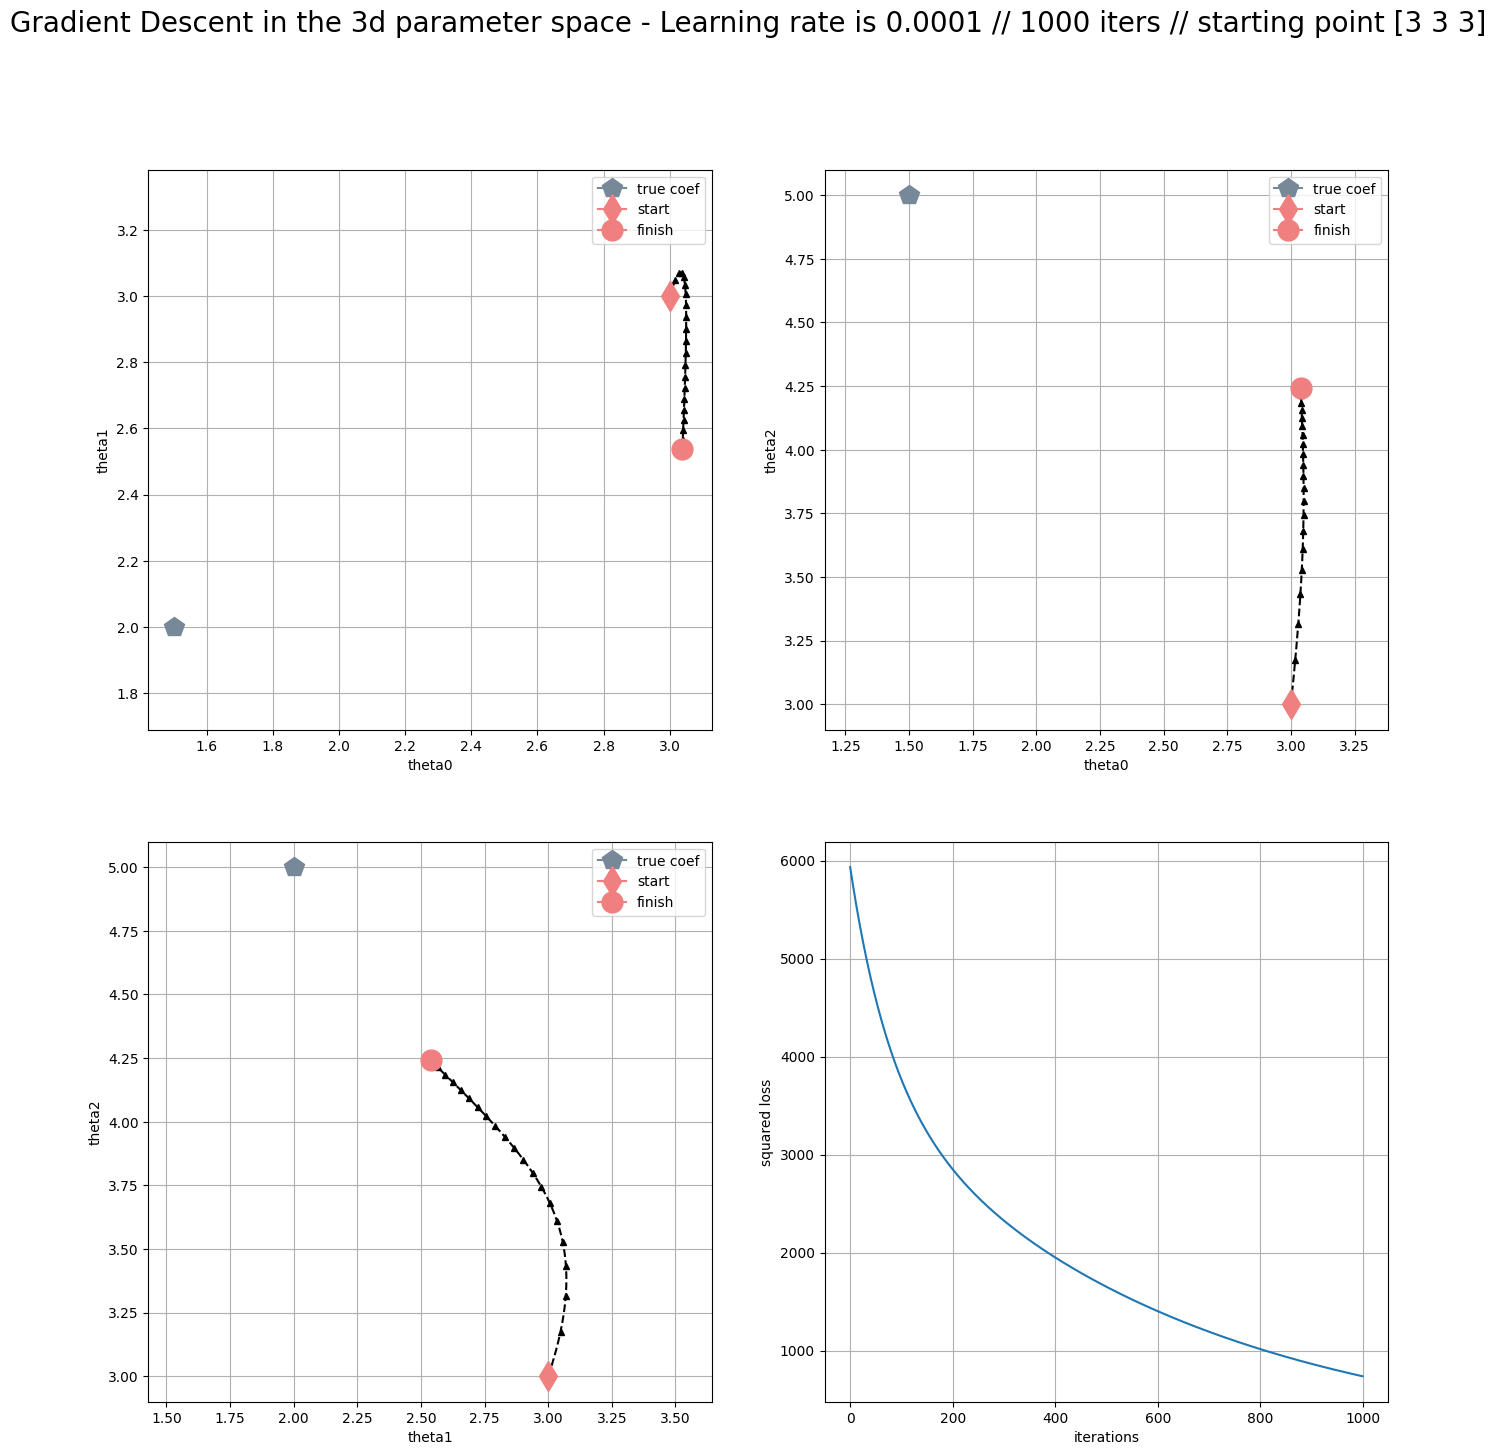

In [12]:
true_coef = [bias, theta_1, theta_2]

def plot_ij(theta_path, i, j, ax):
    ax.plot(true_coef[i], true_coef[j],
            marker='p', markersize=15, label='true coef', 
            color='#778899')
    ax.plot(theta_path[:, i],theta_path[:, j],
            color='k', linestyle='--', marker='^', 
            markersize=5, markevery=50)
    ax.plot(theta_path[0, i], theta_path[0, j], marker='d', 
            markersize=15, label='start', color='#F08080')
    ax.plot(theta_path[-1, i], theta_path[-1, j], marker='o', 
            markersize=15, label='finish', color='#F08080')
    ax.set(
        xlabel='theta'+str(i),
        ylabel='theta'+str(j))
    ax.axis('equal')
    ax.grid(True)
    ax.legend(loc='best')
    

def plot_all(theta_path, loss_vec, learning_rate, num_iter, theta_initial, gdtype='Gradient Descent'):
    fig = plt.figure(figsize=(16, 16))
    title = '{gdtype} in the 3d parameter space - Learning rate is {lr} // {iters} iters // starting point {initial}'
    title = title.format(gdtype=gdtype, lr=learning_rate, 
                         iters=num_iter, initial=theta_initial)
    fig.suptitle(title, fontsize=20)
    ax = fig.add_subplot(2, 2, 1)
    plot_ij(theta_path, 0, 1, ax)
    ax = fig.add_subplot(2, 2, 2)
    plot_ij(theta_path, 0, 2, ax)
    ax = fig.add_subplot(2, 2, 3)
    plot_ij(theta_path, 1, 2, ax)
    ax = fig.add_subplot(2, 2, 4)
    ax.plot(loss_vec)
    ax.set(xlabel='iterations', ylabel='squared loss')
    ax.grid(True)
    

theta_path, loss_vec = gradient_descent(learning_rate, num_iters, theta_initial)
plot_all(theta_path, loss_vec, learning_rate, num_iters, theta_initial)



## Stochastic Gradient Descent
Rather than average the gradients across the whole dataset before taking a step, we will now take a step for every datapoint.  Each step will be somewhat of an "overreaction" but they should average out.

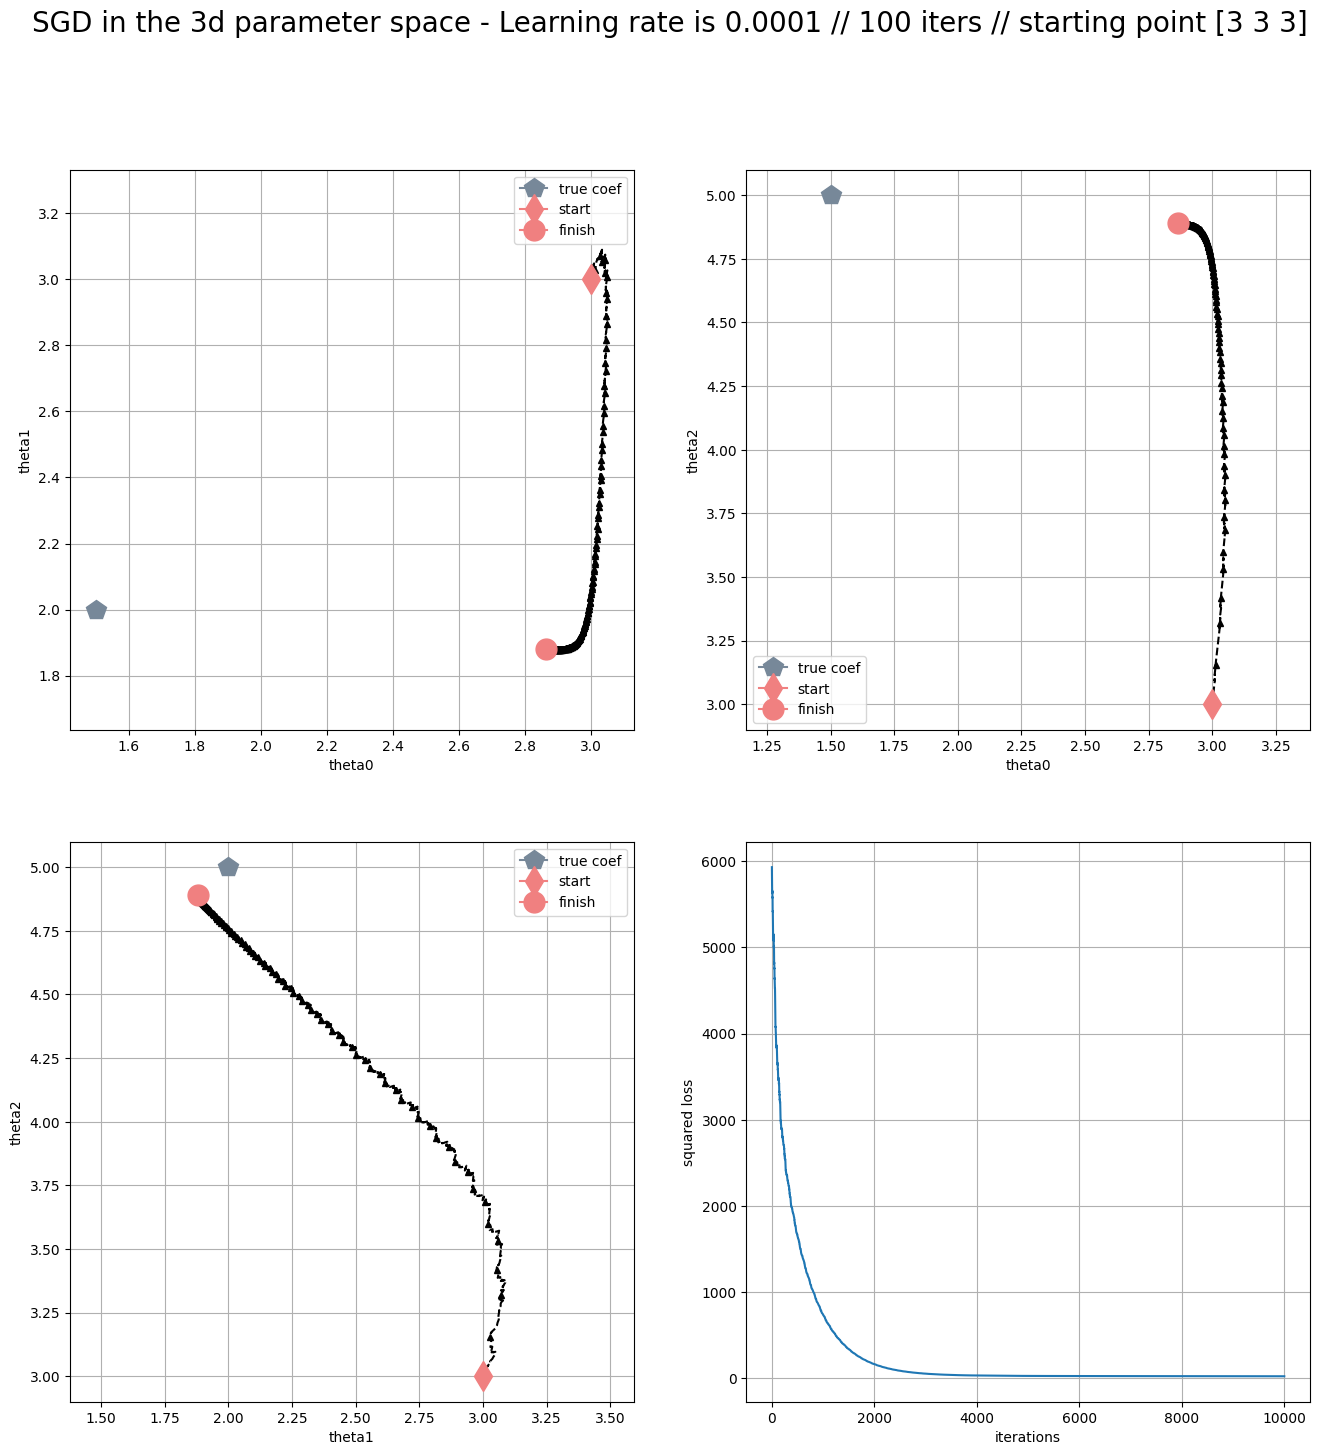

In [13]:
# helper function for the stochastic gradient descent
def sgd(learning_rate, iterations, theta_init):

    theta = theta_init
    theta_path = np.zeros(((iterations * observations) + 1, 3))
    theta_path[0, :] = theta_init
    loss_vec = np.zeros(iterations * observations)

    count = 0

    for i in range(iterations):
        for j in range(observations):

            count += 1
            y_hat = np.dot(theta.T, x_matrix.T)
            loss_vec[count-1] = np.sum((y - y_hat) ** 2)
            grad_vec = (y[j] - y_hat[j]) * (x_matrix[j, :])
            theta = theta + learning_rate * grad_vec
            theta_path[count, :] = theta

    return theta_path, loss_vec

# provide valid parameters
learning_rate = 1e-4
num_iter = 100
theta_initial = np.array([3, 3, 3])

theta_path, loss_vec = sgd(learning_rate, num_iter, theta_initial)
plot_all(theta_path, loss_vec, learning_rate, 
         num_iter, theta_initial, 'SGD')